# Calculus for Deep Learning — Hands-On

**What you'll do here:**

1. Write functions and their derivatives in code
2. Compute partial derivatives for multi-input functions
3. Build the gradient `∇L`
4. Apply the **chain rule** to compute `∂L/∂w` for a single neuron
5. Run **gradient descent** to train one weight from scratch

Same notation as the videos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Functions

A function is a machine — give it `x`, it returns `y`.

Same example from the video:

$$f(x) = x^2$$

In [2]:
def f(x):
    return x ** 2

print("f(2)  =", f(2))
print("f(3)  =", f(3))
print("f(-1) =", f(-1))

f(2)  = 4
f(3)  = 9
f(-1) = 1


Matches the video: f(2)=4, f(3)=9, f(-1)=1. Let's plot it:

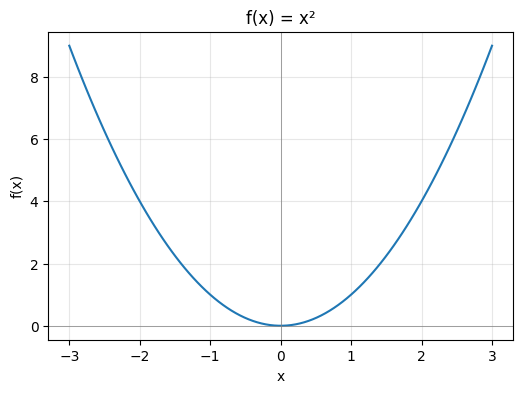

In [3]:
x_vals = np.linspace(-3, 3, 100)

plt.figure(figsize=(6, 4))
plt.plot(x_vals, f(x_vals))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("f(x) = x²")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(alpha=0.3)
plt.show()

## 2. Derivatives

The **derivative** tells you the slope at a point — how fast `y` changes when you change `x`.

**Power rule** (from the video):

$$\frac{d}{dx}(x^n) = n \cdot x^{n-1}$$

So for $f(x) = x^2$, the derivative is $f'(x) = 2x$.

In [6]:
def f_prime(x):
    return 2 * x        # derivative of x² is 2x

print("slope at x=3 :", f_prime(3))      # 6
print("slope at x=2 :", f_prime(2))      # 4
print("slope at x=0 :", f_prime(0))      # 0  (minimum point)
print("slope at x=-1:", f_prime(-1))     # -2
print("slope at x=-3:", f_prime(-3))     # -2

slope at x=3 : 6
slope at x=2 : 4
slope at x=0 : 0
slope at x=-1: -2
slope at x=-3: -6


Notice — slope is positive on the right side, negative on the left, zero at the bottom. That's exactly the shape of the curve we just plotted.

Let's also verify the video's example $L = \omega^2 + 3\omega + 5$ where at $\omega = 2$ the slope should be $7$:

In [9]:
# dL/dw
def L_prime(w):
    return 2*w + 3       # derivative of w² + 3w + 5

print("slope at w=2:", L_prime(2))     # +7

# +ve slope means loss goes UP if we increase w.
# So to REDUCE loss, we DECREASE w. (That's gradient descent.)


slope at w=2: 7


## 3. Partial Derivatives

When a function has *many* inputs, we nudge **one variable** and **freeze the rest**.

From the video:

$$f(x_1, x_2) = x_1^2 + 3x_1 x_2 + x_2^2$$

Partial derivatives:
- $\dfrac{\partial f}{\partial x_1} = 2x_1 + 3x_2$  (treat $x_2$ as constant)
- $\dfrac{\partial f}{\partial x_2} = 3x_1 + 2x_2$  (treat $x_1$ as constant)

In [10]:
def df_dx1(x1, x2):
    return 2*x1 + 3*x2

def df_dx2(x1, x2):
    return 3*x1 + 2*x2

# Evaluate at (x1=2, x2=1)
x1, x2 = 2, 1

print("∂f/∂x1 at (2, 1) =", df_dx1(x1, x2))     # 7
print("∂f/∂x2 at (2, 1) =", df_dx2(x1, x2))     # 8

∂f/∂x1 at (2, 1) = 7
∂f/∂x2 at (2, 1) = 8


## 4. The Gradient `∇L`

The gradient is just a **list of all partial derivatives** — one per weight.

$$\nabla L = \left[\frac{\partial L}{\partial w_1},\ \frac{\partial L}{\partial w_2},\ \dots,\ \frac{\partial L}{\partial w_n}\right]$$

Toy example with 3 weights:
$$L(w_1, w_2, w_3) = w_1^2 + 2w_2^2 + 3w_3^2$$

Partials: $\dfrac{\partial L}{\partial w_1} = 2w_1$,  $\dfrac{\partial L}{\partial w_2} = 4w_2$,  $\dfrac{\partial L}{\partial w_3} = 6w_3$

In [11]:
def gradient(w):
    return np.array([2*w[0], 4*w[1], 6*w[2]])

w = np.array([1.0, 2.0, 3.0])

print("weights w :", w)
print("gradient ∇L:", gradient(w))    # [2, 8, 18]

weights w : [1. 2. 3.]
gradient ∇L: [ 2.  8. 18.]


The gradient points in the direction of **increasing** loss. To reduce loss, we step in the **opposite** direction.

## 5. The Chain Rule

The weight `w` doesn't directly touch the loss `L` — there are stages in between:

$$x \;\rightarrow\; z = wx + b \;\rightarrow\; \hat{y} = \sigma(z) \;\rightarrow\; L = (\hat{y} - y)^2$$

Chain rule bridges them by multiplying the **local derivatives** at each step:

$$\frac{\partial L}{\partial w} \;=\; \underbrace{\frac{\partial L}{\partial \hat{y}}}_{2(\hat{y}-y)} \;\cdot\; \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\sigma'(z)} \;\cdot\; \underbrace{\frac{\partial z}{\partial w}}_{x}$$

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# --- Setup: one neuron, one training example ---
x = 1.5            # input
y = 1.0            # true label
w = 0.4            # weight
b = 0.1            # bias

# --- Forward pass ---
z      = w * x + b
y_hat  = sigmoid(z)
L      = (y_hat - y) ** 2


print(f"z      = {z:.4f}")
print(f"y_hat  = {y_hat:.4f}")
print(f"Loss L = {L:.4f}")

# --- Backward pass: 3 pieces, multiplied ---
dL_dyhat = 2 * (y_hat - y)         # piece 1
dyhat_dz = sigmoid_derivative(z)   # piece 2
dz_dw    = x                       # piece 3

dL_dw = dL_dyhat * dyhat_dz * dz_dw

print(f"\nPiece 1  ∂L/∂ŷ = 2(ŷ-y)   = {dL_dyhat:.4f}")
print(f"Piece 2  ∂ŷ/∂z = σ'(z)    = {dyhat_dz:.4f}")
print(f"Piece 3  ∂z/∂w = x        = {dz_dw:.4f}")
print(f"\n=> ∂L/∂w = {dL_dw:.6f}")

z      = 0.7000
y_hat  = 0.6682
Loss L = 0.1101

Piece 1  ∂L/∂ŷ = 2(ŷ-y)   = -0.6636
Piece 2  ∂ŷ/∂z = σ'(z)    = 0.2217
Piece 3  ∂z/∂w = x        = 1.5000

=> ∂L/∂w = -0.220701


**That's the chain rule.** Three small derivatives, multiplied together, give us exactly what we need: *"how much does the loss change if we wiggle this one weight?"*

## 6. Gradient Descent — Train One Weight

Now we use that gradient to actually *improve* the weight. The update rule from the video:

$$w \leftarrow w - \alpha \cdot \nabla L$$

We'll start with a bad weight, run the loop, and watch the loss drop.

In [13]:
# --- Same setup, but with a bad initial weight ---
x = 1.5
y = 1.0
b = 0.1
w = -2.0          # bad starting point
alpha = 0.5       # learning rate

loss_history   = []
weight_history = []

for step in range(50):
    # Forward pass
    z     = w * x + b
    y_hat = sigmoid(z)
    L     = (y_hat - y) ** 2

    # Backward pass — chain rule
    dL_dw = 2*(y_hat - y) * sigmoid_derivative(z) * x

    # Update
    w = w - alpha * dL_dw

    loss_history.append(L)
    weight_history.append(w)

    if step % 10 == 0:
        print(f"step {step:2d} | w = {w:+.4f} | y_hat = {y_hat:.4f} | loss = {L:.6f}")

print(f"\nFinal: w = {w:.4f}, prediction = {sigmoid(w*x+b):.4f}, target = {y}")

step  0 | w = -1.9297 | y_hat = 0.0522 | loss = 0.898413
step 10 | w = -0.6058 | y_hat = 0.2454 | loss = 0.569372
step 20 | w = +0.7870 | y_hat = 0.7661 | loss = 0.054728
step 30 | w = +1.1624 | y_hat = 0.8588 | loss = 0.019950
step 40 | w = +1.3561 | y_hat = 0.8919 | loss = 0.011676

Final: w = 1.4740, prediction = 0.9098, target = 1.0


Loss drops, weight settles, prediction creeps toward the target. Let's see it:

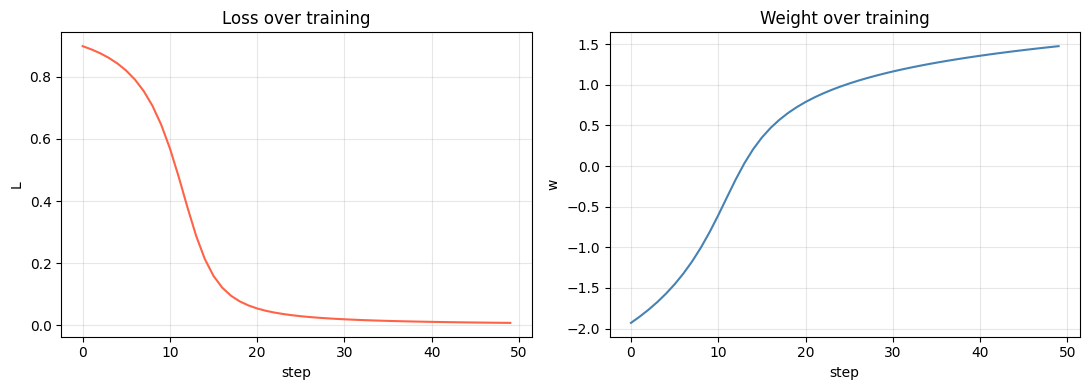

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(loss_history, color='tomato')
axes[0].set_title("Loss over training")
axes[0].set_xlabel("step"); axes[0].set_ylabel("L")
axes[0].grid(alpha=0.3)

axes[1].plot(weight_history, color='steelblue')
axes[1].set_title("Weight over training")
axes[1].set_xlabel("step"); axes[1].set_ylabel("w")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**That's gradient descent.** We just trained a tiny neural network with one weight. The loop is *identical* to what PyTorch runs for a 100-billion-parameter model:

1. Forward pass → compute loss
2. Backward pass → chain rule gives gradients
3. Update → `w ← w - α·∇L`
4. Repeat

## 7. Bonus — Watching the Descent on the Loss Curve

Same hill-and-valley picture from the video — but now with real numbers.

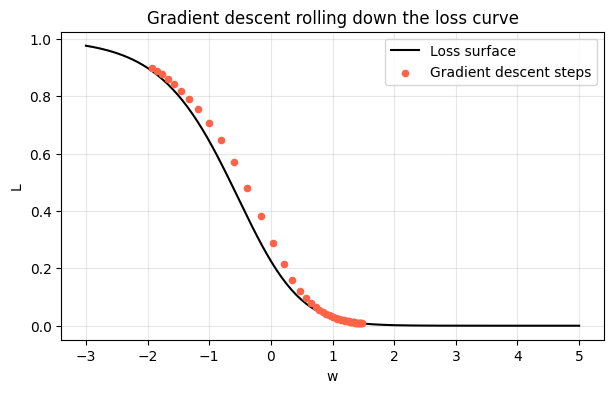

In [15]:
# Sweep w across a range; for each w, compute loss
def loss_of_w(w_val):
    z = w_val * x + b
    return (sigmoid(z) - y) ** 2

w_grid     = np.linspace(-3, 5, 200)
loss_curve = [loss_of_w(wv) for wv in w_grid]

plt.figure(figsize=(7, 4))
plt.plot(w_grid, loss_curve, color='black', label="Loss surface")
plt.scatter(weight_history, loss_history, color='tomato', s=20,
            zorder=3, label="Gradient descent steps")
plt.title("Gradient descent rolling down the loss curve")
plt.xlabel("w"); plt.ylabel("L")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Red dots are our actual update steps — sliding down the curve into the minimum.

## 8. Recap

| Concept              | What it does                                                  |
|----------------------|---------------------------------------------------------------|
| Derivative           | Slope of a function at a point                                 |
| Partial derivative   | Slope w.r.t. one variable, freezing the rest                   |
| Gradient `∇L`        | Vector of partials — one per weight                            |
| Chain rule           | Multiply local derivatives through the computation graph       |
| Gradient descent     | `w ← w - α·∇L` repeated until loss stops dropping              |

**Next up:** probability — how the network expresses *confidence* in its outputs.